# 02 — Build graph & clean chargers

Loads the cached graph and raw chargers (wider central-Warsaw inventory), snaps each charger to its nearest road node, drops chargers outside the polygon (snap distance > `MAX_SNAP_DISTANCE_M`), imputes missing port counts, and writes the cleaned table to `data/processed/chargers_clean.csv`.

Per-step diagnostics are printed by `clean_chargers`:
- raw rows downloaded
- after coordinate cleaning
- after port imputation
- after snap-distance boundary filter
- after duplicate-node aggregation
- final station count and total port count

In [1]:
import sys
from pathlib import Path
PROJECT = Path.cwd().resolve().parent
if str(PROJECT) not in sys.path: sys.path.insert(0, str(PROJECT))

import pandas as pd
from src import config, graph_utils, charger_data

print(f'STUDY_AREA_MODE        = {config.STUDY_AREA_MODE}')
print(f'MAX_SNAP_DISTANCE_M    = {config.MAX_SNAP_DISTANCE_M}')
print(f'raw charger CSV path   = {config.RAW_CHARGER_CSV}')
print(f'clean charger CSV path = {config.PROCESSED_CHARGER_CSV}')

STUDY_AREA_MODE        = central_warsaw
MAX_SNAP_DISTANCE_M    = 250.0
raw charger CSV path   = C:\Users\dsuifh\Downloads\Master Thesis Data SGH\ev-charging-warsaw-simulation-v1\ev_thesis\data\raw\chargers_openchargemap_warsaw_wide.csv
clean charger CSV path = C:\Users\dsuifh\Downloads\Master Thesis Data SGH\ev-charging-warsaw-simulation-v1\ev_thesis\data\processed\chargers_clean.csv


In [2]:
G = graph_utils.get_or_build_graph()
print(f'graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

graph: 1,011 nodes, 1,989 edges


In [3]:
df_raw = charger_data.load_chargers(prefer_cached=True)
print(f'raw rows: {len(df_raw):,}')
df_raw.head()

raw rows: 52


,station_id,name,latitude,longitude,operator,number_of_points,source
0,51343,Plac Defilad 1,52.230524,21.007401,NaN,1,openchargemap
1,87389,H15 Boutique Hotel,52.225119,21.011656,NaN,1,openchargemap
2,51344,Emilii Plater,52.231945,21.003838,NaN,1,openchargemap
3,57210,Grupa PKP Energetyka,52.224686,21.007387,NaN,2,openchargemap
4,51342,Piękna 44,52.223168,21.013634,NaN,1,openchargemap


In [4]:
df_clean = charger_data.clean_chargers(df_raw, G)
charger_data.save_clean_chargers(df_clean)
df_clean.head()

[charger_data] cleaning funnel — raw rows: 52
[charger_data]   after cleaning: 52 rows
[charger_data]   snapped: 52 rows  (median snap distance = 3316.4 m, max = 7224.3 m)
[charger_data]   - dropped 35 rows whose snap distance > 250 m (outside graph boundary)
[charger_data]   after graph-boundary filter: 17 rows
[charger_data]   - merged 1 duplicate-node rows by summing ports
[charger_data] FINAL: 16 stations, 27 total ports.


,node,station_id,name,latitude,longitude,operator,number_of_points,source,ports_imputed,snap_distance_m
0,32528278,51346,Budynek RWE - Wybrzeże Kościuszkowskie 41,52.239246,21.030837,(unknown),4,openchargemap,False,34.036725
1,33629032,175522,IBIS Hotel Zagórna,52.226323,21.042568,(unknown),1,openchargemap,False,20.621698
2,33692336,149503,Warsaw Supercharger,52.207736,21.029349,(unknown),2,openchargemap,False,72.064486
3,60861687,57210,Grupa PKP Energetyka,52.224686,21.007387,(unknown),2,openchargemap,False,10.528560
4,105757858,87389,H15 Boutique Hotel,52.225119,21.011656,(unknown),1,openchargemap,False,62.421199


### Sanity check
Map of cleaned chargers (lon/lat scatter on top of all graph nodes).

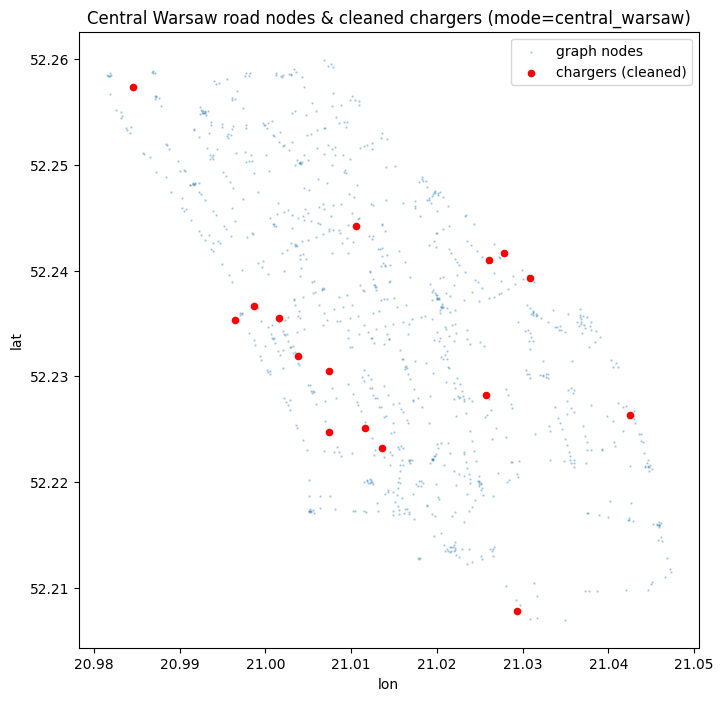

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter([G.nodes[n]['x'] for n in G.nodes], [G.nodes[n]['y'] for n in G.nodes], s=0.5, alpha=0.3, label='graph nodes')
if not df_clean.empty:
    ax.scatter(df_clean['longitude'], df_clean['latitude'], s=20, c='red', label='chargers (cleaned)')
ax.set_xlabel('lon'); ax.set_ylabel('lat'); ax.legend()
ax.set_title(f'Central Warsaw road nodes & cleaned chargers (mode={config.STUDY_AREA_MODE})')
plt.show()